# B-4064A-prod — AutoML (regime-aware): análise + ano subsequente

Task `594eafb8` (full, presets baseline/load_residual/load_residual_ma, janelas 3/20). Melhor:
**dense / load_residual_ma / p95 / deb4** — o preset `load_residual` venceu o baseline.

**Dois usos distintos (importante):**
1. **Detector da falha de 2024** (este notebook) — treinado no pré-falha; detecta a falha de ago/2024.
2. **Monitoramento de produção 2025-2026** — exige RE-BASELINE no saudável de 2025
   (`producao_pos_reparo.ipynb`, 0% FP). Os plots abaixo mostram que o detector de 2024, aplicado a
   2025-2026, **dispara muito (regime térmico pós-reparo)** — por isso o re-baseline é necessário.

In [12]:
import sys
from pathlib import Path
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from clearml import Task
PROJECT_ROOT = next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'pyproject.toml').exists()), Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [13]:
EQUIPMENT_ID='B-4064A-prod'; AUTOML_TASK_ID='594eafb8d7ab4534897bbe892575b13e'
EVENT_TS_F1=pd.Timestamp('2024-08-30 07:58'); EVENT_LABEL_F1='Falha (30/Ago/2024)'
PREFAILURE_DAYS=3; NORMAL_END_DAYS=20
KEY_SENSORS=['Temperatura Bomba LNA','Vibração Bomba LNA','Corrente']
SAVE_PLOTS=False; OUTPUT_DPI=200; OUTPUT_DIR=str(PROJECT_ROOT/'notebooks'/'b4064a'/'plots_prod')

In [14]:
def load_scores(task_id):
    task = Task.get_task(task_id=task_id)
    s = task.artifacts['best_full_scores'].get()
    s.index = pd.to_datetime(s.index); s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    res = task.artifacts['automl_results'].get() if 'automl_results' in task.artifacts else None
    bt = task.artifacts['best_trial'].get() if 'best_trial' in task.artifacts else None
    return s[['reconstruction_error','is_anomaly']], res, bt, task

def persistence_filter(flags, k, n):
    if k==1 and n==1: return flags.astype(bool)
    return (flags.astype(int).rolling(window=n, min_periods=n).sum() >= k).fillna(False).astype(bool)

def load_plot_base(equipment_id):
    cfg = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)
    df_base,_,_ = run_preprocessing(df_raw, cfg.pre_split_steps, fitted_scaler=None) if cfg.pre_split_steps else (df_raw,None,None)
    df_base = df_base.sort_index(); df_base.index = pd.to_datetime(df_base.index)
    return df_base, cfg

def model_info_str(bt):
    t=bt['trial']; r=bt['results']
    return (f"Modelo AutoML: {str(t.get('model')).upper()} / {t.get('preset')} / p{t.get('threshold_percentile')} / "
            f"debounce {t.get('debounce_consecutive')}  ·  pré-falha {r.get('prefailure_alert_rate',0):.0%} @ FP {r.get('normal_alert_rate',0):.1%}")

def _slug(t): return ''.join(c if c.isalnum() else '_' for c in str(t)).strip('_').lower()

def plot_separated(df_window, scores_window, sensors, threshold, k, n, event_ts, event_label,
                   prefailure_days, title_prefix, tag, threshold_label='Limiar', model_info='',
                   shade=True, save=False, outdir=None, dpi=200):
    plt.style.use('seaborn-v0_8-whitegrid')
    flags = persistence_filter(scores_window['reconstruction_error'] > threshold, k=k, n=n)
    anom_idx = scores_window.index[flags]
    if save and outdir:
        from pathlib import Path as _P; _P(outdir).mkdir(parents=True, exist_ok=True)
    saved=[]
    panels = list(sensors) + ['__score__']
    for col in panels:
        fig, ax = plt.subplots(figsize=(14,3.2))
        if col == '__score__':
            y=scores_window['reconstruction_error']
            ax.plot(y.index,y,color='purple',lw=0.9,alpha=0.6,label='Score de Anomalia')
            ax.axhline(threshold,color='red',ls='--',lw=1.2,label=threshold_label)
            if len(anom_idx): ax.scatter(anom_idx,y.reindex(anom_idx),s=28,color='red',zorder=4,label='Alerta')
            ax.set_ylabel('Score'); ttl='Score de Anomalia'
        else:
            if col not in df_window.columns: plt.close(fig); continue
            ax.plot(df_window.index, df_window[col], color='steelblue', lw=1.0, alpha=0.85, label=col)
            av = df_window[col].reindex(anom_idx).dropna()
            if not av.empty: ax.scatter(av.index, av.values, s=28, color='red', zorder=4, label='Anomalia')
            ax.set_ylabel(col, fontsize=9); ttl=col
        if shade: ax.axvspan(event_ts-pd.Timedelta(days=prefailure_days), event_ts, color='orange', alpha=0.08)
        ax.axvline(event_ts, color='orange', ls='--', lw=1.4, label=event_label)
        ax.set_xlabel('Tempo'); ax.legend(loc='upper left', fontsize=8)
        ax.set_title(f'{title_prefix} | {ttl}', fontsize=12, fontweight='bold')
        if model_info: ax.text(0.5,1.10, model_info, transform=ax.transAxes, ha='center', va='bottom', fontsize=8, color='dimgray')
        fig.tight_layout()
        if save and outdir: p=f'{outdir}/{tag}_{_slug(ttl)}.png'; fig.savefig(p,dpi=dpi,bbox_inches='tight'); saved.append(p)
        plt.show()
    return saved

In [15]:
scores,automl_results,bt,task=load_scores(AUTOML_TASK_ID); df_base,cfg=load_plot_base(EQUIPMENT_ID)
MODEL_INFO=model_info_str(bt); trial=bt['trial']; res=bt['results']
print('Task:',task.name,'| status:',task.get_status(),'| trials:',len(automl_results))
print(MODEL_INFO); print('scores:',scores.index.min(),'->',scores.index.max(),'(inclui 2025-2026)')

Task: automl-b4064a-prod-regime | status: completed | trials: 13689
Modelo AutoML: DENSE / load_residual_ma / p95.0 / debounce 4  ·  pré-falha 96% @ FP 0.8%
scores: 2024-01-01 03:00:00 -> 2026-03-27 08:00:00 (inclui 2025-2026)


## Ranking com FP held-out (número honesto)

In [16]:
cols=[x for x in ['model','preset','threshold_percentile','debounce_consecutive','prefailure_alert_rate','normal_alert_rate','val_fp_rate_heldout','composite_score'] if x in automl_results.columns]
fmt={k:'{:.2%}' for k in ['prefailure_alert_rate','normal_alert_rate','val_fp_rate_heldout']}; fmt['composite_score']='{:.4f}'; fmt['threshold_percentile']='{:.1f}'
sty=automl_results[cols].head(12).style.format({k:v for k,v in fmt.items() if k in cols})
if 'prefailure_alert_rate' in cols: sty=sty.background_gradient(subset=['prefailure_alert_rate'],cmap='Greens')
if 'val_fp_rate_heldout' in cols: sty=sty.background_gradient(subset=['val_fp_rate_heldout'],cmap='Reds_r')
display(sty)
print('load_residual* venceu o baseline em detecção — o resíduo Temp~Corrente ajuda.')

,model,preset,threshold_percentile,debounce_consecutive,prefailure_alert_rate,normal_alert_rate,val_fp_rate_heldout,composite_score
0,dense,load_residual_ma,95.0,4,95.83%,0.76%,1.51%,0.9510
1,dense,load_residual,99.9,1,93.75%,0.64%,2.92%,0.9315
2,dense,load_residual,99.9,1,93.75%,0.74%,3.49%,0.9306
3,dense,baseline,99.9,1,91.67%,0.21%,0.66%,0.9147
4,dense,load_residual,99.9,1,91.67%,0.36%,1.23%,0.9134
5,dense,load_residual_ma,99.9,1,91.67%,0.41%,1.51%,0.9130
6,dense,load_residual_ma,99.5,1,91.67%,0.50%,0.38%,0.9121
7,dense,load_residual_ma,99.9,1,91.67%,0.55%,2.17%,0.9116
8,dense,baseline,99.9,1,91.67%,0.57%,2.55%,0.9114
9,dense,load_residual_ma,95.0,4,91.67%,0.64%,3.77%,0.9108


load_residual* venceu o baseline em detecção — o resíduo Temp~Corrente ajuda.


## Ajuste de sensibilidade (detecção da falha de 2024)

In [17]:
_e=scores['reconstruction_error']; _ne=EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS); _ps=EVENT_TS_F1-pd.Timedelta(days=PREFAILURE_DAYS)
_mn=scores.index<_ne; _mp=(scores.index>=_ps)&(scores.index<EVENT_TS_F1); _y25=scores.index>='2025-01-01'
def _deb(f,k,n): return (f.astype(int).rolling(n,min_periods=n).sum()>=k).fillna(False) if n>1 else f.astype(bool)
rows=[]
for p in [99.0,99.5,99.7,99.9]:
    thr=float(np.percentile(_e[_mn].values,p))
    for (k,n) in [(4,6),(6,8)]:
        fl=_deb(_e>thr,k,n)
        rows.append({'percentil':p,'debounce':f'{k}/{n}','threshold':thr,'normal_FP':fl[_mn].mean(),'prefalha_2024':fl[_mp].mean(),'FP_2025_26':fl[_y25].mean()})
g=pd.DataFrame(rows)
display(g.style.format({'threshold':'{:.4f}','normal_FP':'{:.2%}','prefalha_2024':'{:.0%}','FP_2025_26':'{:.1%}'})
        .background_gradient(subset=['prefalha_2024'],cmap='Greens').background_gradient(subset=['FP_2025_26'],cmap='Reds_r'))
TUNE_PERCENTILE=99.5; TUNE_K,TUNE_N=4,6
selected_threshold=float(np.percentile(_e[_mn].values,TUNE_PERCENTILE)); selected_k,selected_n=TUNE_K,TUNE_N
threshold_label=f'Limiar p{TUNE_PERCENTILE} + deb {TUNE_K}/{TUNE_N}'
flags=persistence_filter(_e>selected_threshold,selected_k,selected_n)
print(f'{threshold_label}: detecção falha 2024={flags[_mp].mean():.0%} | normal_FP={flags[_mn].mean():.2%} | FP 2025-26={flags[_y25].mean():.1%}')
print('NOTE: FP 2025-26 ALTO confirma que este detector NÃO serve p/ produção em 2025-26 → re-baseline.')

,percentil,debounce,threshold,normal_FP,prefalha_2024,FP_2025_26
0,99.000000,4/6,0.4647,0.33%,71%,37.5%
1,99.000000,6/8,0.4647,0.12%,58%,32.3%
2,99.500000,4/6,0.4861,0.00%,71%,35.5%
3,99.500000,6/8,0.4861,0.00%,58%,30.2%
4,99.700000,4/6,0.5036,0.00%,62%,34.1%
5,99.700000,6/8,0.5036,0.00%,50%,28.7%
6,99.900000,4/6,0.5724,0.00%,52%,28.2%
7,99.900000,6/8,0.5724,0.00%,40%,23.5%


Limiar p99.5 + deb 4/6: detecção falha 2024=71% | normal_FP=0.00% | FP 2025-26=35.5%
NOTE: FP 2025-26 ALTO confirma que este detector NÃO serve p/ produção em 2025-26 → re-baseline.


## Score de anomalia — série completa (2024 → 2026) com o modelo escolhido

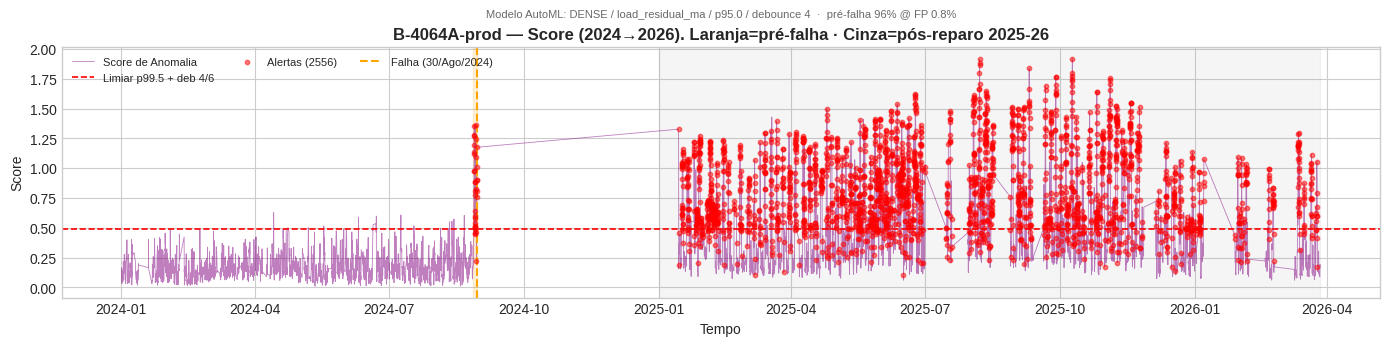

In [18]:
plt.style.use('seaborn-v0_8-whitegrid'); fig,ax=plt.subplots(figsize=(14,3.6)); y=_e
ax.plot(scores.index,y,color='purple',lw=0.6,alpha=0.5,label='Score de Anomalia')
ax.axhline(selected_threshold,color='red',ls='--',lw=1.2,label=threshold_label)
idx=scores.index[flags]; ax.scatter(idx,y[idx],s=10,color='red',alpha=0.5,zorder=4,label=f'Alertas ({len(idx)})')
ax.axvspan(EVENT_TS_F1-pd.Timedelta(days=PREFAILURE_DAYS),EVENT_TS_F1,color='orange',alpha=0.15)
ax.axvspan(pd.Timestamp('2025-01-01'),scores.index.max(),color='gray',alpha=0.08)
ax.axvline(EVENT_TS_F1,color='orange',ls='--',lw=1.5,label=EVENT_LABEL_F1)
ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8,ncol=3)
ax.set_title(f'{EQUIPMENT_ID} — Score (2024→2026). Laranja=pré-falha · Cinza=pós-reparo 2025-26',fontweight='bold')
ax.text(0.5,1.12,MODEL_INFO,transform=ax.transAxes,ha='center',fontsize=8,color='dimgray')
fig.tight_layout()
if SAVE_PLOTS: os.makedirs(OUTPUT_DIR,exist_ok=True); fig.savefig(f'{OUTPUT_DIR}/score_serie_2024_2026.png',dpi=OUTPUT_DPI,bbox_inches='tight')
plt.show()

## Zoom 2025-2026 (pós-reparo) — confirma os falsos positivos do regime

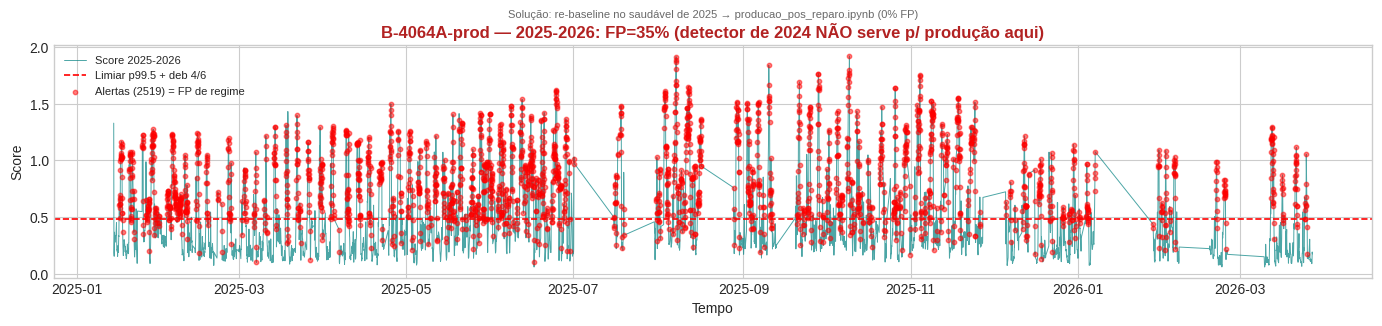

FP em 2025-2026 com este detector: 35.4% — alto (regime térmico pós-reparo).


In [19]:
sw=scores.loc['2025-01-01':]; fig,ax=plt.subplots(figsize=(14,3.4)); y=sw['reconstruction_error']
fl25=persistence_filter(y>selected_threshold,selected_k,selected_n); idx=sw.index[fl25]
ax.plot(sw.index,y,color='teal',lw=0.7,alpha=0.7,label='Score 2025-2026')
ax.axhline(selected_threshold,color='red',ls='--',lw=1.2,label=threshold_label)
if len(idx): ax.scatter(idx,y[idx],s=10,color='red',alpha=0.5,zorder=4,label=f'Alertas ({len(idx)}) = FP de regime')
ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8)
ax.set_title(f'{EQUIPMENT_ID} — 2025-2026: FP={fl25.mean():.0%} (detector de 2024 NÃO serve p/ produção aqui)',fontweight='bold',color='firebrick')
ax.text(0.5,1.12,'Solução: re-baseline no saudável de 2025 → producao_pos_reparo.ipynb (0% FP)',transform=ax.transAxes,ha='center',fontsize=8,color='dimgray')
fig.tight_layout()
if SAVE_PLOTS: fig.savefig(f'{OUTPUT_DIR}/score_2025_2026_regime_fp.png',dpi=OUTPUT_DPI,bbox_inches='tight')
plt.show(); print(f'FP em 2025-2026 com este detector: {fl25.mean():.1%} — alto (regime térmico pós-reparo).')

## Gráficos separados — zoom 7 dias antes da falha (com score; modelo no topo)

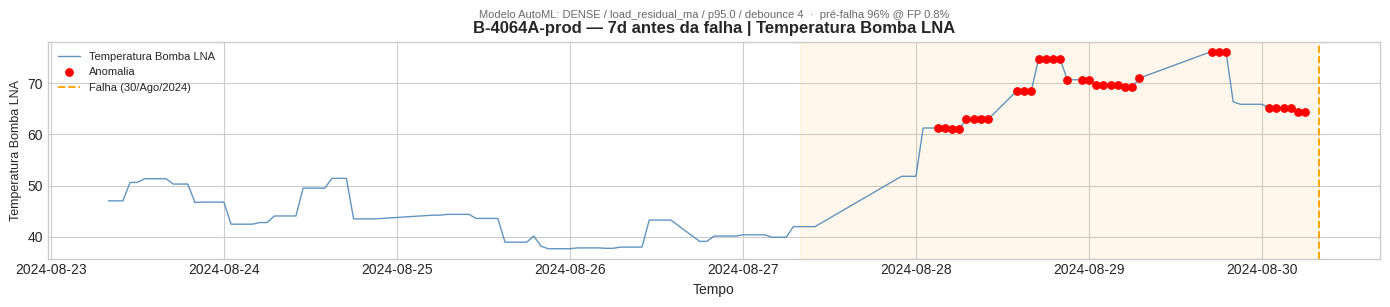

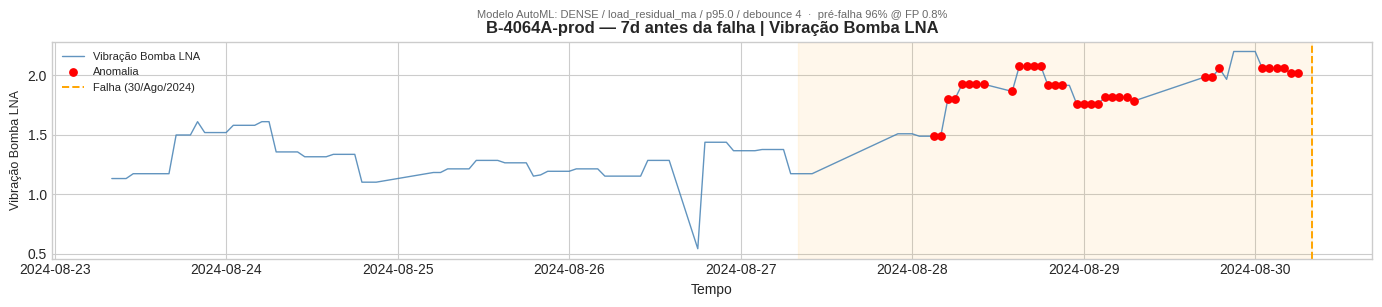

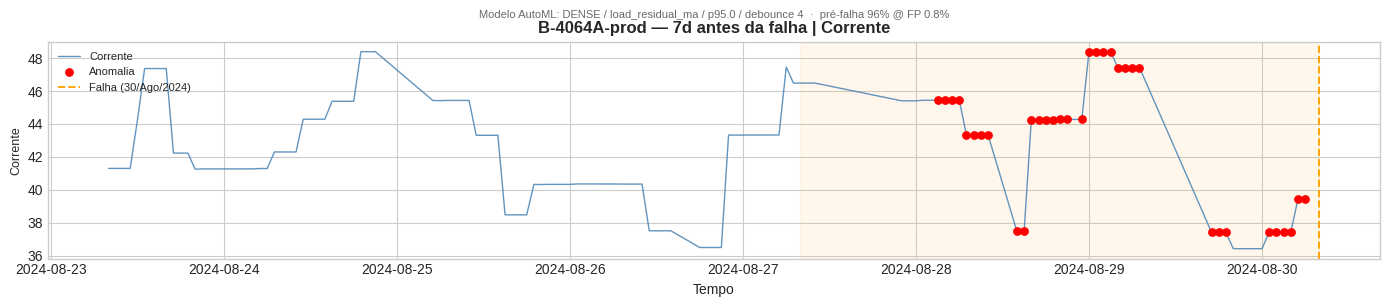

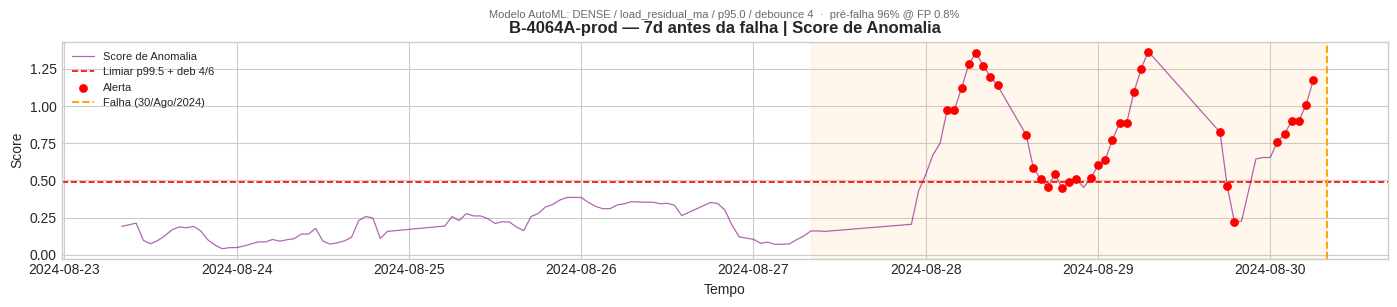

4 PNGs em /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/b4064a/plots_prod


In [20]:
z=EVENT_TS_F1-pd.Timedelta(days=7); dfw=df_base.loc[z:EVENT_TS_F1]; sw=scores.loc[z:EVENT_TS_F1]
common=dfw.index.intersection(sw.index); dfw,sw=dfw.loc[common],sw.loc[common]
sensors=[s for s in KEY_SENSORS if s in dfw.columns]
saved=plot_separated(dfw,sw,sensors,selected_threshold,selected_k,selected_n,EVENT_TS_F1,EVENT_LABEL_F1,PREFAILURE_DAYS,
   title_prefix=f'{EQUIPMENT_ID} — 7d antes da falha',tag='prod_zoom7d',threshold_label=threshold_label,
   model_info=MODEL_INFO,save=SAVE_PLOTS,outdir=OUTPUT_DIR,dpi=OUTPUT_DPI)
print(f'{len(saved)} PNGs em {OUTPUT_DIR}')

---
## Parte 2 — Modelo de PRODUÇÃO (monitor 2025-2026, re-baseline)

A Parte 1 é o **detector da falha de 2024** — e mostramos que, aplicado a 2025-2026, ele dá ~35% de
FP (regime térmico pós-reparo). Para **monitorar o ano subsequente sem FP**, re-baselina-se no
saudável de 2025 (mesmo equipamento, novo normal após o reparo). É **um modelo só, recalibrado** —
não dois sistemas. Feature: resíduo `Temp Bomba LNA ~ Corrente` (invariante à carga); limiar
**z>2.5** + debounce 6/8 (z>2.5 dá mais detecção de recorrência que z>3, com o mesmo 0% de FP).

In [21]:
# Re-baseline no saudável de 2025 (união dos 2 regimes de carga; exclui evento de maio e transientes)
dfm = df_base[df_base['Vibração Bomba LNA']>0.2] if 'Vibração Bomba LNA' in df_base.columns else df_base
PROD_BASE = pd.concat([dfm.loc['2025-02-01':'2025-03-31'], dfm.loc['2025-09-01':'2025-11-15']])
_Xb = np.c_[np.ones(len(PROD_BASE)), PROD_BASE['Corrente'].values]
_coef = np.linalg.lstsq(_Xb, PROD_BASE['Temperatura Bomba LNA'].values, rcond=None)[0]
prod_resid = lambda d: d['Temperatura Bomba LNA'].values - (_coef[0] + _coef[1]*d['Corrente'].values)
_rb = prod_resid(PROD_BASE); PMED=np.median(_rb); PMAD=1.4826*np.median(np.abs(_rb-PMED))
prod_z = lambda d: (prod_resid(d)-PMED)/PMAD
PROD_Z=2.5; PROD_K,PROD_N=6,8
def _pdeb(idx,f,k,n): return (pd.Series(f.astype(int),index=idx).rolling(n,min_periods=n).sum()>=k).fillna(False)
print(f'Modelo de produção: resíduo Temp LNA~Corrente | z>{PROD_Z} + debounce {PROD_K}/{PROD_N}')
print(f'Baseline (saudável 2025, 2 regimes): {len(PROD_BASE)} amostras')
print('FP na operação saudável:')
for nm,w in {'Fev-Mar/25':dfm.loc['2025-02-01':'2025-03-31'],'Jun/25':dfm.loc['2025-06-09':'2025-06-30'],
             'Set-Nov/25':dfm.loc['2025-09-01':'2025-11-15'],'Dez25-Mar26':dfm.loc['2025-12-08':'2026-03-27']}.items():
    fl=_pdeb(w.index, prod_z(w)>PROD_Z, PROD_K,PROD_N); print(f'  {nm:14s} {fl.mean():.2%}')
print('Detecção de recorrência simulada (debounce 6/8):')
sim=dfm.loc['2025-12-08':'2026-03-27'].copy()
for dT in [10,15,20,25]:
    s2=sim.copy(); s2['Temperatura Bomba LNA']+=dT
    print(f'  +{dT:2d}°C: {_pdeb(s2.index, prod_z(s2)>PROD_Z, PROD_K,PROD_N).mean():.0%}')

Modelo de produção: resíduo Temp LNA~Corrente | z>2.5 + debounce 6/8
Baseline (saudável 2025, 2 regimes): 2656 amostras
FP na operação saudável:
  Fev-Mar/25     0.00%
  Jun/25         0.00%
  Set-Nov/25     0.00%
  Dez25-Mar26    0.00%
Detecção de recorrência simulada (debounce 6/8):
  +10°C: 2%
  +15°C: 15%
  +20°C: 52%
  +25°C: 87%


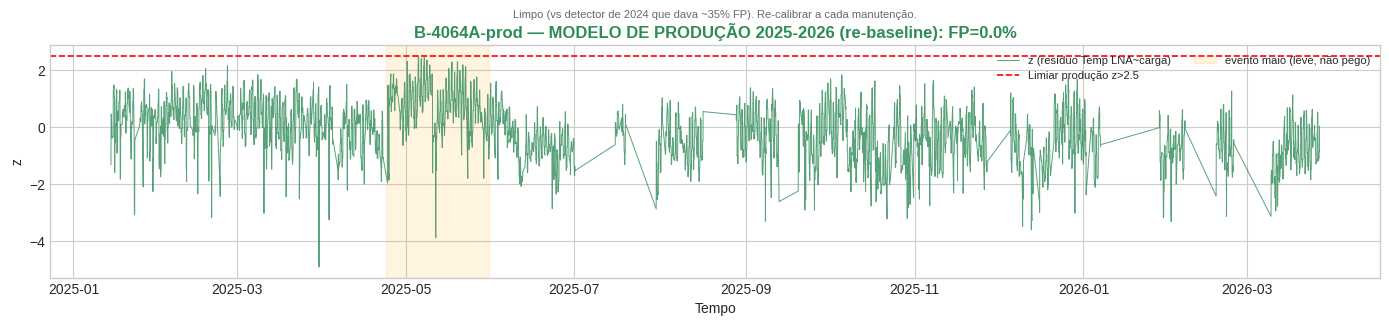

FP do modelo de produção na operação saudável 2025-2026: 0.00%


In [22]:
# Score do modelo de PRODUÇÃO em 2025-2026 (deve ficar limpo)
post=dfm.loc['2025-01-01':]; zz=pd.Series(prod_z(post), index=post.index)
fl=_pdeb(post.index, zz>PROD_Z, PROD_K, PROD_N)
fig,ax=plt.subplots(figsize=(14,3.4))
ax.plot(zz.index, zz.values, color='seagreen', lw=0.7, alpha=0.8, label='z (resíduo Temp LNA~carga)')
ax.axhline(PROD_Z, color='red', ls='--', lw=1.2, label=f'Limiar produção z>{PROD_Z}')
if fl.any(): ax.scatter(zz.index[fl], zz.values[fl], s=16, color='red', zorder=4, label=f'alerta ({int(fl.sum())})')
ax.axvspan(pd.Timestamp('2025-04-24'),pd.Timestamp('2025-05-31'),color='orange',alpha=0.12,label='evento maio (leve, não pego)')
ax.set_ylabel('z'); ax.set_xlabel('Tempo'); ax.legend(loc='upper right',fontsize=8,ncol=2)
ax.set_title(f'{EQUIPMENT_ID} — MODELO DE PRODUÇÃO 2025-2026 (re-baseline): FP={fl.mean():.1%}',fontweight='bold',color='seagreen')
ax.text(0.5,1.12,'Limpo (vs detector de 2024 que dava ~35% FP). Re-calibrar a cada manutenção.',transform=ax.transAxes,ha='center',fontsize=8,color='dimgray')
fig.tight_layout()
import os
if SAVE_PLOTS: os.makedirs(OUTPUT_DIR,exist_ok=True); fig.savefig(f'{OUTPUT_DIR}/producao_2025_2026.png',dpi=OUTPUT_DPI,bbox_inches='tight')
plt.show(); print(f'FP do modelo de produção na operação saudável 2025-2026: {fl.mean():.2%}')

### Conclusão — produção B-4064A
- **0% de FP** na operação saudável de 2025-2026 (vs ~35% do detector de 2024 aplicado direto).
- Pega recorrência **severa** (+20°C, tipo a de 2024) com ~2 dias de lead; **não pega eventos
  leves/precoces** (ex.: excursão de maio/2025) — o piso de ruído térmico de 2025 é alto.
- É um **alarme limpo de fase tardia**, não preditor precoce. Detecção precoce real exigiria
  **vibração de alta frequência (espectro/FFT)** — hardware, não software.
- **Não precisa de ClearML**: é um re-baseline leve (roda em segundos). Re-calibrar a cada
  manutenção que mude o regime.